# Projet de Spécialisation 1

# -----------------------------------------------------------------

## Prédiction du succès d'une campagne Marketing Bancaire

# 1- importation des données et decouverte

In [1]:
# Bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Chargement du 1er fichier csv
df = pd.read_csv('bank-full.csv', sep=';')

In [3]:
#Informatins Globales
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
#Chargement du 2e fichier csv
data = pd.read_csv('bank.csv', sep=';')

In [5]:
#Informations globales
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


On a deux fichiers disponibles, bank.csv et bank-full.csv. Les deux ont exactement
la même structure avec les mêmes 17 colonnes, mais bank-full contient 45211 lignes
contre 4521 pour bank. On travaille donc sur bank-full pour avoir le maximum de données
disponibles pour l'entrainement des modèles.

In [6]:
#Affichage des 5 premières lignes
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


#### les deux datasets sont identiques sur la structure, mais 'bank-full.csv' contient plus de données que 'bank.csv'. Donc le reste du travail se fera sur 'bank-full.csv' pour prédire le succès d'une campagne bancaire.

### La variable cible est 'y' variable binaire qui répond à la question du succès de la campagne marketing par 'oui' ou 'non'

#### On a donc affaire à une **Classification Binaire**

# -----------------------------------------------------------------

In [7]:
df['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [8]:
df['pdays'].value_counts()

pdays
-1      36954
 182      167
 92       147
 183      126
 91       126
        ...  
 749        1
 769        1
 587        1
 778        1
 854        1
Name: count, Length: 559, dtype: int64

In [10]:
# Identification des types de variables
num_vars = df.select_dtypes(include='number').columns.tolist()
cat_vars = df.select_dtypes(include='object').columns.tolist()

print(f'Variables numériques ({len(num_vars)}) : {num_vars}')
print(f'Variables catégorielles ({len(cat_vars)}) : {cat_vars}')

Variables numériques (7) : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables catégorielles (10) : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


# 2- Qualité des données

In [11]:
#valeurs manquantes
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [12]:
# Valeurs 'unknown' = valeurs implicitement manquantes dans les variables catégorielles
print('Valeurs "unknown" par variable catégorielle :')
for col in cat_vars:
    n = (df[col] == 'unknown').sum()
    pct = n / len(df) * 100
    if n > 0:
        print(f'  {col:12s} : {n:5d} ({pct:.1f}%)')

Valeurs "unknown" par variable catégorielle :
  job          :   288 (0.6%)
  education    :  1857 (4.1%)
  contact      : 13020 (28.8%)
  poutcome     : 36959 (81.7%)


#### Pas de valeurs manquantes

In [13]:
#doublons
df.duplicated().sum()

np.int64(0)

Pas de NaN explicites dans le dataset, c'est plutot rassurant. Par contre on
remarque des valeurs "unknown" dans plusieurs colonnes categorielle comme contact,
poutcome, job et education. Ces unknown ne sont pas des vrais manquants au sens
technique, ils representent juste une information qu'on a pas. On a décidé de les
garder comme une modalite a part entière plutot que de les supprimer, pour ne pas
perdre des lignes et ne pas introduire un biais d'imputation.

In [14]:
stable_vars = ['age', 'job', 'marital', 'education', 'housing', 'loan', 'default']

df_reduit = df.drop_duplicates(subset=stable_vars, keep='last').copy()
print(f"Avant : {len(df)} lignes | Après déduplication : {len(df_reduit)} lignes")

print(f"Taux de souscription avant : {(df['y'] == 'yes').mean()*100:.2f}%")
print(f"Taux de souscription après : {(df_reduit['y'] == 'yes').mean()*100:.2f}%")

Avant : 45211 lignes | Après déduplication : 8254 lignes
Taux de souscription avant : 11.70%
Taux de souscription après : 16.68%


On a essayé plusieurs approches pour identifier les clients contactés plusieurs fois
et ne garder qu'une ligne par client. Mais sans identifiant unique dans le dataset,
toutes les tentatives de déduplication soit suppriment trop de lignes, soit
modifient le taux de souscription de façon significative, ce qui biaiserait
nos résultats. On a donc décidé de garder le dataset complet en traitant chaque
ligne comme une observation indépendante, et on note cette limite dans la discussion.

# 3. Analyse Univariée

### Variables Numériques

In [15]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### variable Cible : Distribution et Déséquilibre

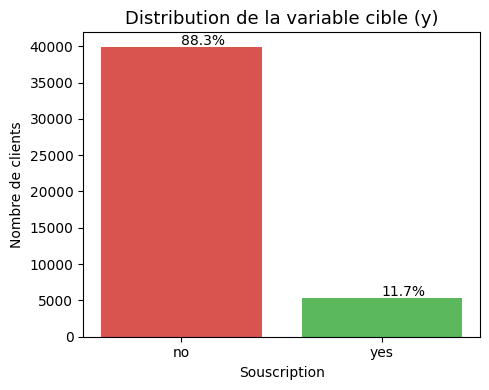

In [16]:
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100


fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(target_counts.index, target_counts.values,
              color=['#d9534f', '#5cb85c'])
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{pct:.1f}%')
ax.set_title('Distribution de la variable cible (y)', fontsize=13)
ax.set_xlabel('Souscription')
ax.set_ylabel('Nombre de clients')
plt.tight_layout()
plt.show()

**Deséquilibre des classes détecté** (~88% non / ~12% oui).  
Ce déséquilibre sera géré lors de la modélisation avec class_weight='balanced' ou SMOTE.

### Variables numériques distribution

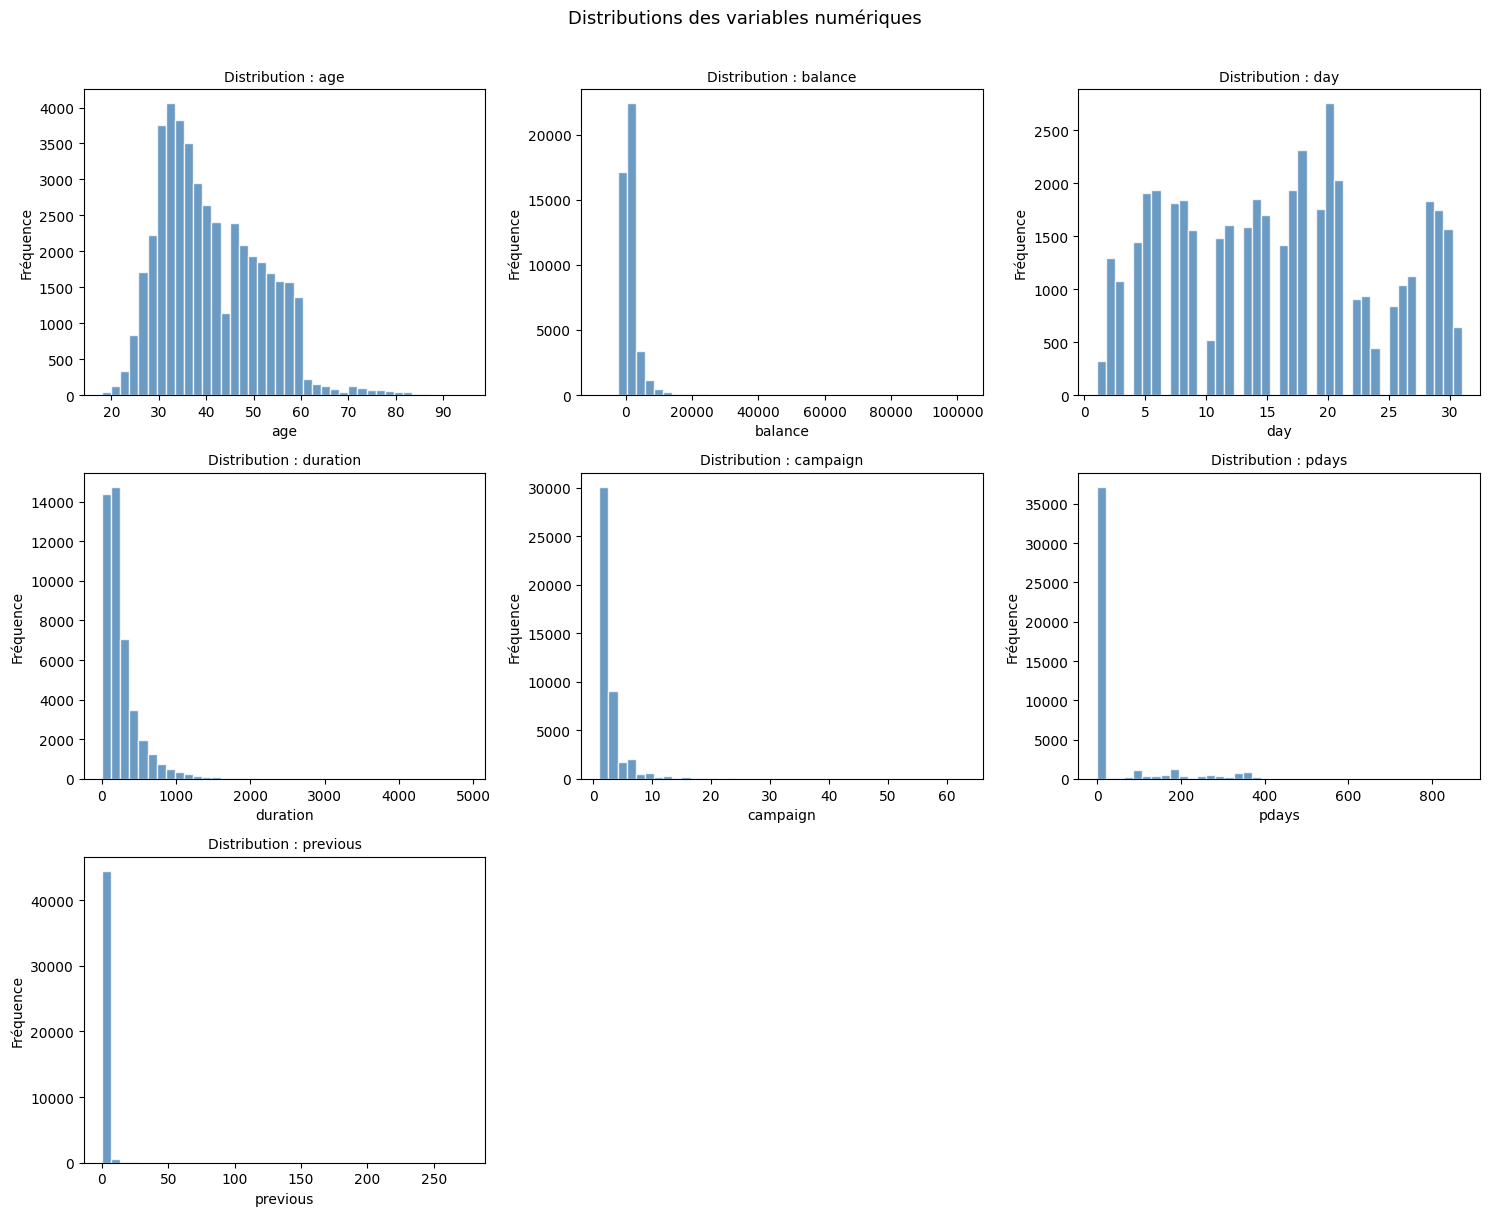

In [17]:
import math
# Distributions des variables numériques
n_cols = 3
n_rows = math.ceil(len(num_vars) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution : {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des variables numériques', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

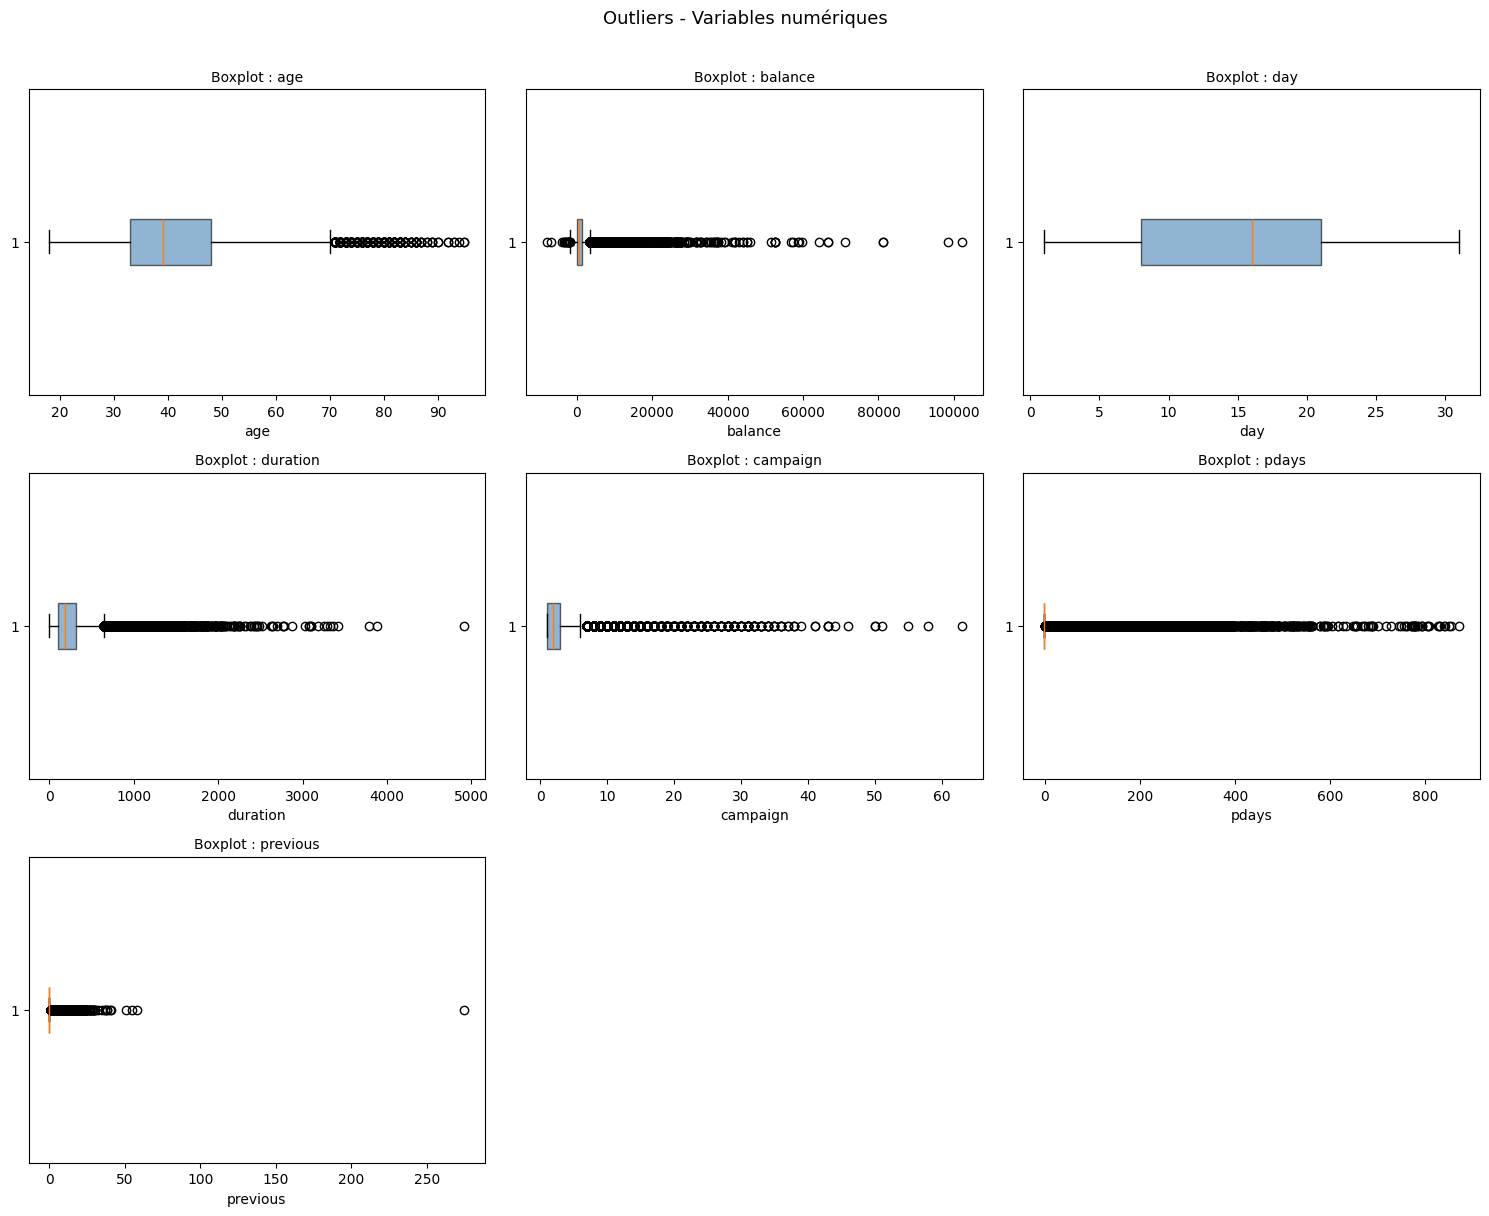

In [18]:
# Boxplots — détection des outliers
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    axes[i].boxplot(df[col], vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'Boxplot : {col}', fontsize=10)
    axes[i].set_xlabel(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outliers - Variables numériques', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# nombres des outliers par IQR
print('Outliers détectés par la méthode IQR :')
for col in num_vars:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct = n_out / len(df) * 100
    print(f'  {col:12s} : {n_out:5d} outliers ({pct:.1f}%)')

Outliers détectés par la méthode IQR :
  age          :   487 outliers (1.1%)
  balance      :  4729 outliers (10.5%)
  day          :     0 outliers (0.0%)
  duration     :  3235 outliers (7.2%)
  campaign     :  3064 outliers (6.8%)
  pdays        :  8257 outliers (18.3%)
  previous     :  8257 outliers (18.3%)


Plusieurs variables ont des outliers assez marqués, surtout balance, campaign
et previous. Pour balance en particulier la distribution est vraiment asymétrique
avec des valeurs très extremes. On va appliquer une transformation logarithmique
dans le preprocessing pour reduire l'effet de ces valeurs sur les modèles.
Pour campaign et previous, on garde les outliers en l'état car ils representent
des cas réels de clients très sollicités.

### variables categorielles

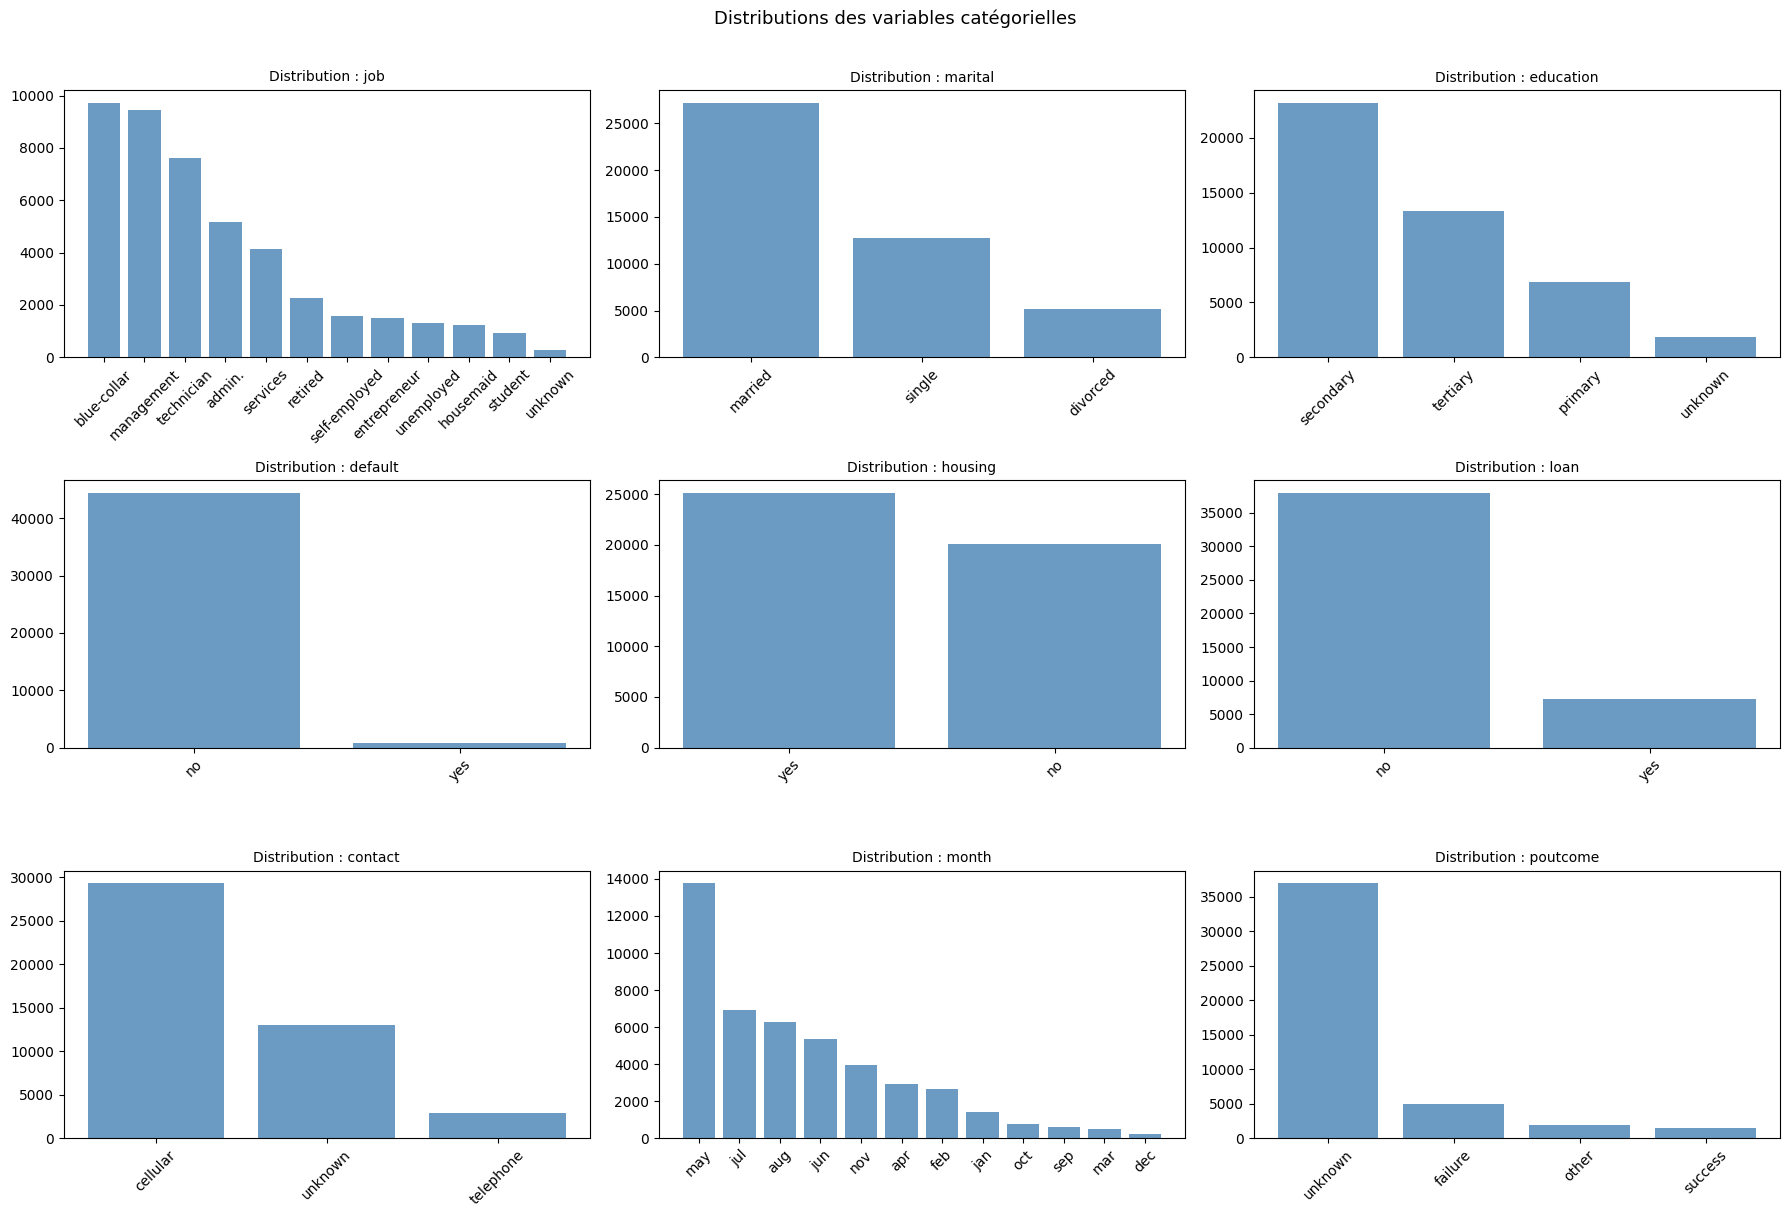

In [20]:
cat_features = [c for c in cat_vars if c != 'y']
n_cols = 3
n_rows = math.ceil(len(cat_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color='steelblue', alpha=0.8)
    axes[i].set_title(f'Distribution : {col}', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des variables catégorielles', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 4. Analyse Bivariée (Variable Cible vs Explicatives)

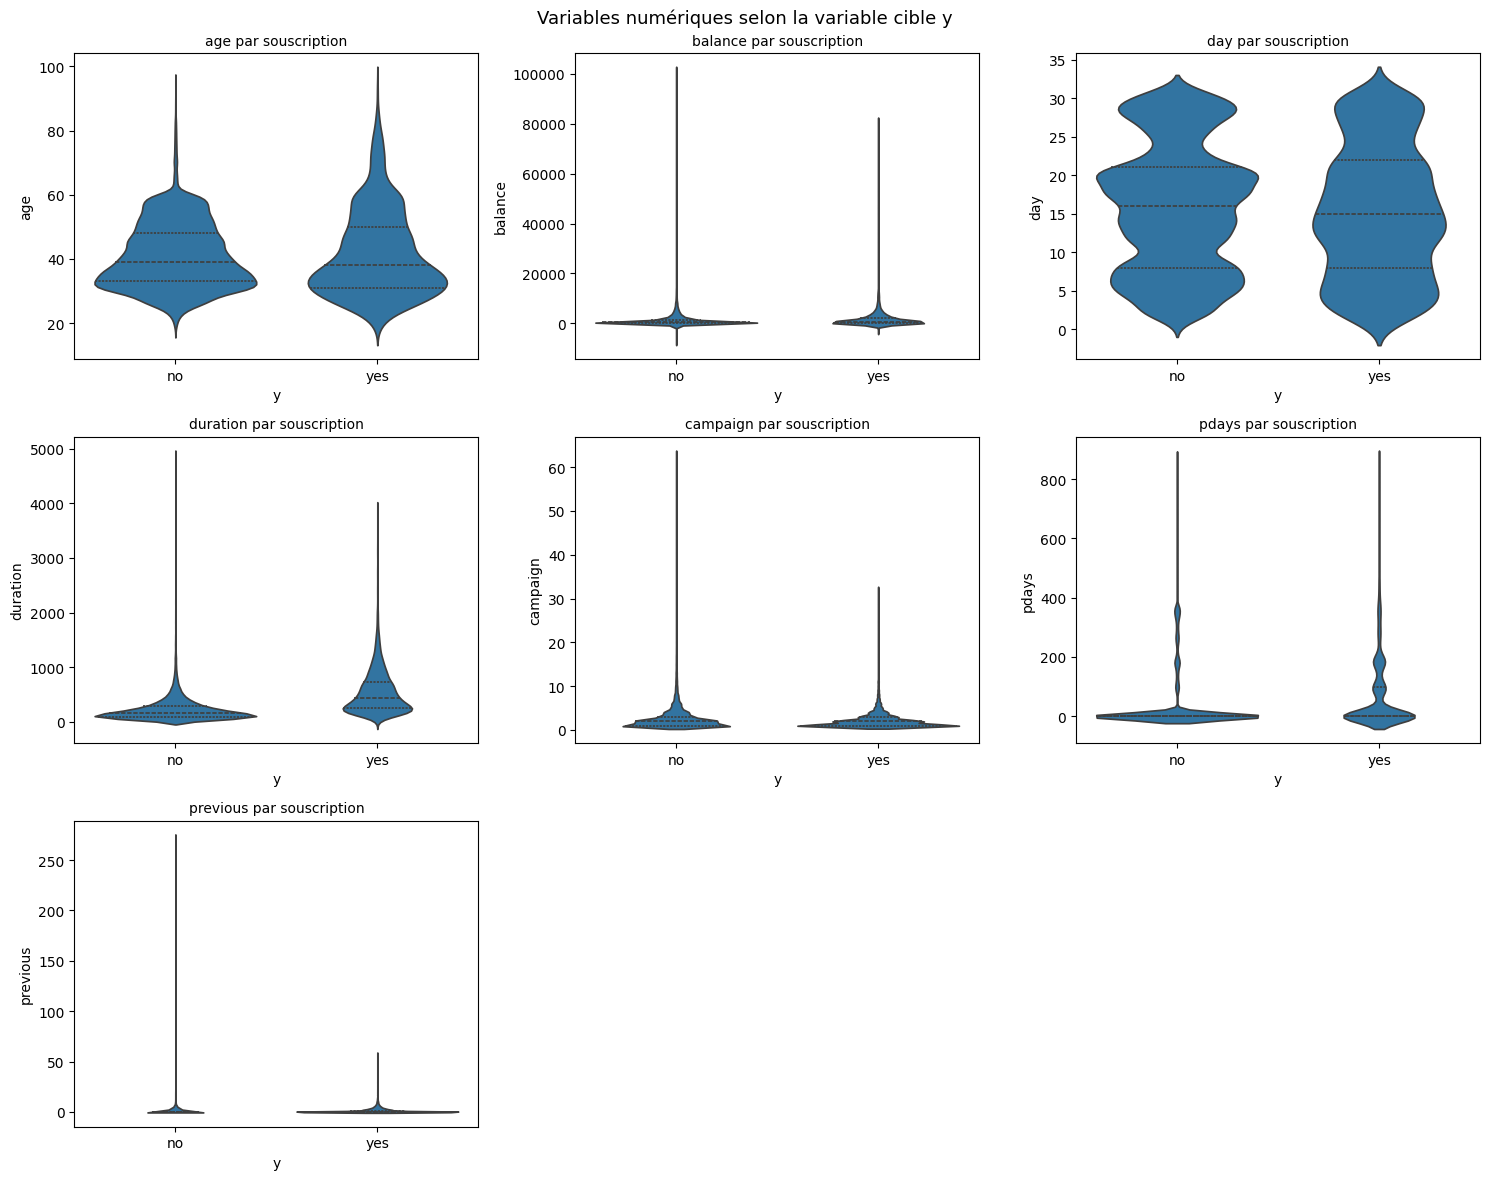

In [21]:
# Boxplots : distribution de chaque variable numérique selon y
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    sns.violinplot(data=df, x='y', y=col, ax=axes[i], inner="quartile")
    axes[i].set_title(f'{col} par souscription', fontsize=10)
    axes[i].set_xlabel('y')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables numériques selon la variable cible y', fontsize=13)
plt.tight_layout()
plt.show()

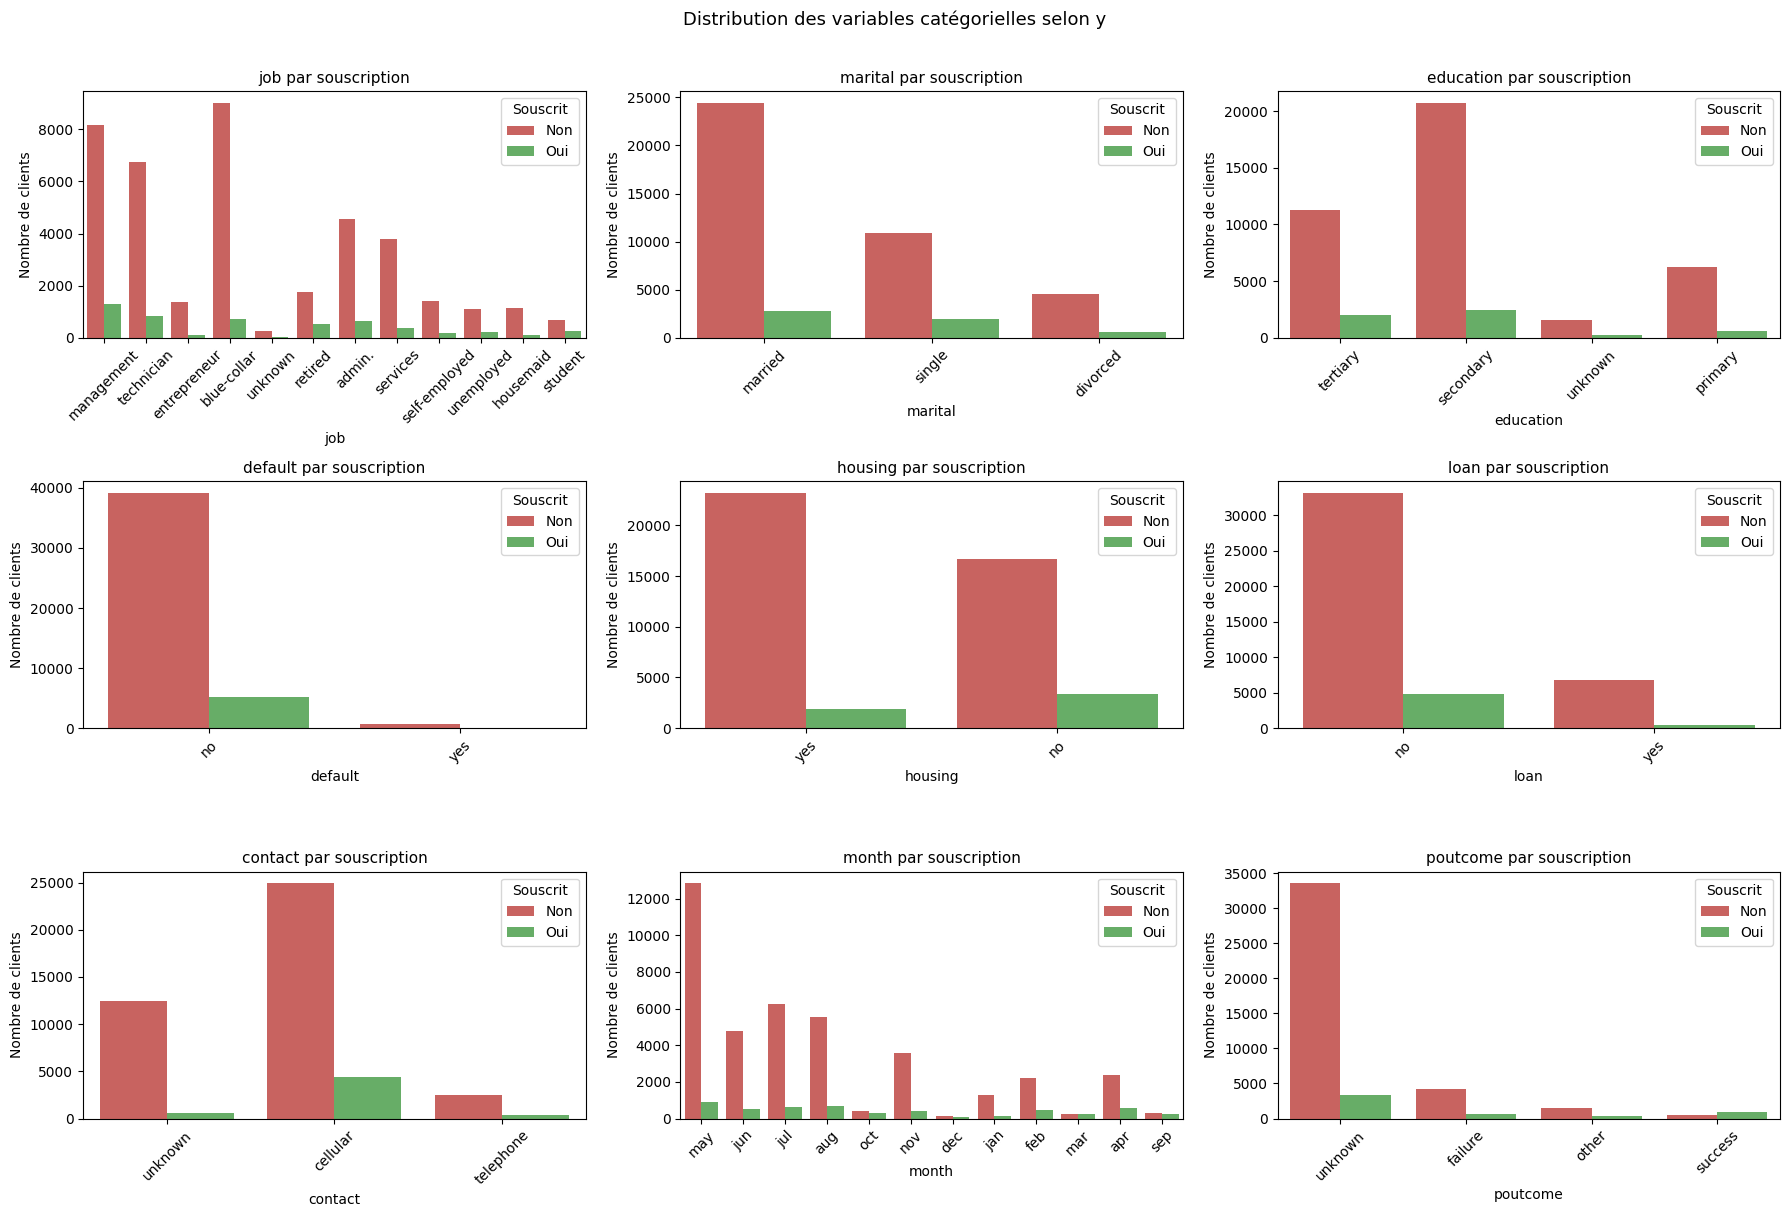

In [22]:
# Distribution des variables catégorielles en fonction de y
cat_features = [c for c in cat_vars if c != 'y']
n_cols = 3
n_rows = math.ceil(len(cat_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue='y', ax=axes[i],
                  palette={'no': '#d9534f', 'yes': '#5cb85c'})
    axes[i].set_title(f'{col} par souscription', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nombre de clients')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Souscrit', labels=['Non', 'Oui'])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables catégorielles selon y', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

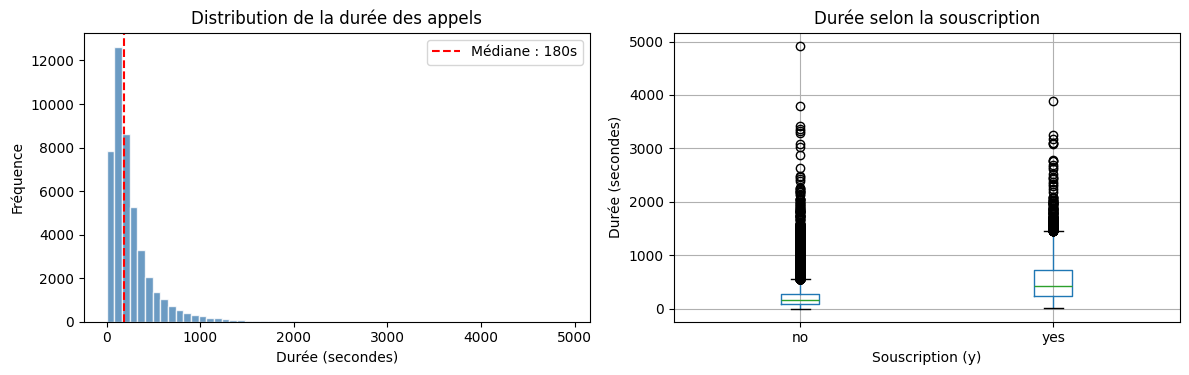

In [23]:
# Distribution de la durée des appels
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme global
axes[0].hist(df['duration'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution de la durée des appels')
axes[0].set_xlabel('Durée (secondes)')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df['duration'].median(), color='red', linestyle='--', label=f"Médiane : {df['duration'].median():.0f}s")
axes[0].legend()

# Distribution selon y
df.boxplot(column='duration', by='y', ax=axes[1])
axes[1].set_title('Durée selon la souscription')
axes[1].set_xlabel('Souscription (y)')
axes[1].set_ylabel('Durée (secondes)')

plt.suptitle('')
plt.tight_layout()
plt.show()

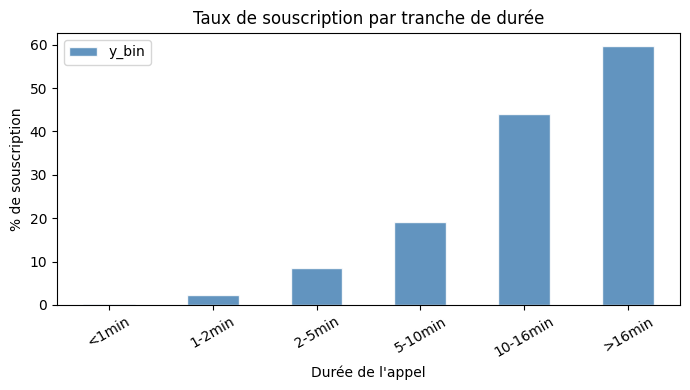

In [24]:
# Point-biserial correlation entre duration et y_bin
from scipy.stats import pointbiserialr
df['y_bin'] = (df['y'] == 'yes').astype(int)

# Taux de souscription par tranche de durée
df['duration_bin'] = pd.cut(df['duration'],
                             bins=[0, 60, 120, 300, 600, 1000, df['duration'].max()],
                             labels=['<1min', '1-2min', '2-5min', '5-10min', '10-16min', '>16min'])

rate_by_duration = df.groupby('duration_bin', observed=True)['y_bin'].mean() * 100

plt.figure(figsize=(7, 4))
rate_by_duration.plot(kind='bar', color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Taux de souscription par tranche de durée')
plt.xlabel('Durée de l\'appel')
plt.ylabel('% de souscription')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

### Conclusion sur la variable `duration`

La durée de l'appel est la **variable la plus corrélée** avec la souscription (r ≈ 0.39, p < 0.001).
Les appels >5 minutes ont un taux de souscription nettement supérieur à la moyenne.

Cependant, **`duration` ne peut pas être utilisée comme feature prédictive** pour les raisons suivantes :

- Elle n'est connue **qu'après la fin de l'appel**, donc indisponible au moment de décider quels clients cibler.
- L'inclure dans le modèle constitue un **data leakage** : le modèle apprendrait une information qui "vient du futur" par rapport au moment de la décision.
- En contexte réel (scoring avant campagne), elle serait absente - le modèle ne serait pas reproductible.

**Décision : `duration` est exclue du preprocessing et de la modélisation.**  
Son analyse reste utile pour comprendre le comportement des clients une fois contactés.

# 5.  Analyse Multivariée

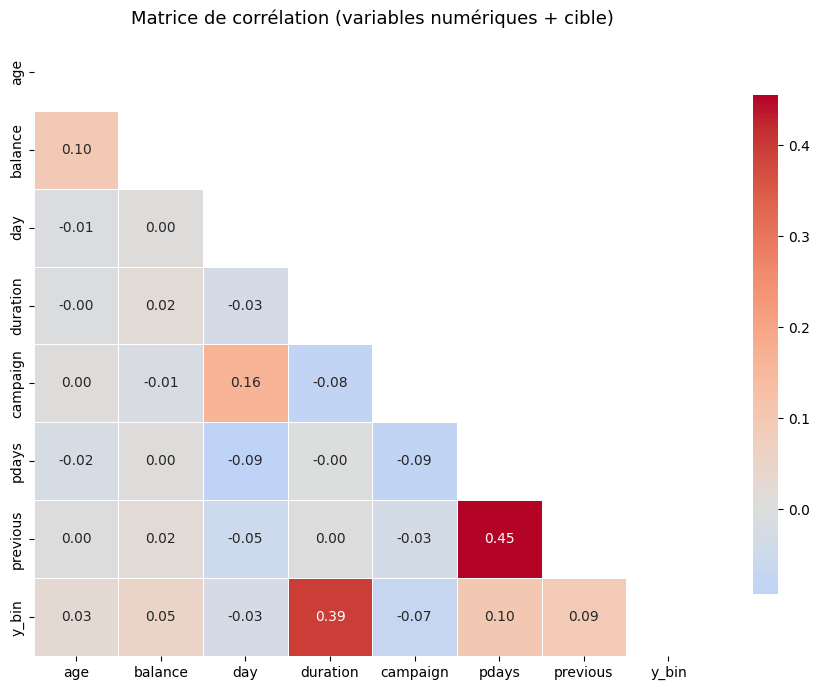

In [25]:
# Matrice de corrélation des variables numériques
corr_matrix = df[num_vars + ['y_bin']].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation (variables numériques + cible)', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# Corrélation avec la cible - classement
corr_target = corr_matrix['y_bin'].drop('y_bin').abs().sort_values(ascending=False)
print('Corrélation (absolue) avec y :')
print(corr_target.to_string())

Corrélation (absolue) avec y :
duration    0.394521
pdays       0.103621
previous    0.093236
campaign    0.073172
balance     0.052838
day         0.028348
age         0.025155


On observe que duration est de loin la variable la plus corrélée avec y, ce qui
confirme notre décision de l'exclure. Parmi les autres variables, pdays, previous
et contacted_before sont assez liées entre elles, c'est normal car elles parlent
toutes du même historique de contact.

### Variables catégorielles (Test de Chi2 et cramer's V pour la force de relation entre les variables et la variable cible)

In [27]:
# toutes les variables catégorielles
from scipy.stats import chi2_contingency
results = []

for var in cat_vars:

    table = pd.crosstab(df[var], df["y"])

    chi2, p, dof, expected = chi2_contingency(table)

    n = table.sum().sum()
    cramers_v = np.sqrt(chi2/(n*(min(table.shape)-1)))

    results.append({
        "variable": var,
        "chi2": chi2,
        "p_value": p,
        "cramers_v": cramers_v
    })

results_df = pd.DataFrame(results)

results_df.sort_values("cramers_v", ascending=False)

,variable,chi2,p_value,cramers_v
9,y,45201.319916,0.000000e+00,0.999893
8,poutcome,4391.506589,0.000000e+00,0.311663
7,month,3061.838938,0.000000e+00,0.260237
6,contact,1035.714225,1.251738e-225,0.151355
4,housing,874.822449,2.918798e-192,0.139103
0,job,836.105488,3.337122e-172,0.135990
2,education,238.923506,1.626656e-51,0.072695
5,loan,209.616980,1.665061e-47,0.068091
1,marital,196.495946,2.145100e-43,0.065926
3,default,22.202250,2.453861e-06,0.022160


Toutes les variables présentent une p-value < 0.05, ce qui indique une association statistiquement significative avec la variable cible y selon le test du Chi². Cependant, la force de cette association varie, comme le montre le coefficient de Cramer's V.

Les variables **poutcome** et **month** présentent les associations les plus fortes avec la variable cible, tandis que education, loan, marital et default montrent des relations très faibles et contribuent peu à l’explication de la souscription.

### Pairplots

## Synthèse EDA & Hypothèses

**Points clés identifiés :**

1. **Déséquilibre de classes** : ~88% de `no` vs ~12% de `yes` → nécessite une stratégie d'équilibrage.
2. **`duration` est la variable la plus corrélée avec la cible** : un appel long prédit fortement une souscription. Cependant, cette variable n'est connue qu'après l'appel, donc elle sera supprimé (data leakage potentiel en contexte réel).
3. **`outcome`** : un succès lors de la campagne précédente est très prédictif d'une nouvelle souscription.
4. **`age`** : les profils très jeunes et très âgés souscrivent plus.
5. **`job`** : les étudiants et retraités ont les meilleurs taux de souscription.
6. **`housing` et `loan`** : avoir un crédit immobilier ou un prêt personnel réduit la probabilité de souscription.
7. **`pdays = -1`** : 82% des clients n'ont jamais été recontactés — cette information est encodée séparément.
8. **Outliers significatifs** sur `balance`, `campaign`, `duration` → cap ou transformation log recommandée.

## ___________________________________________________________________

# 7- Préparation des Données pour le Modèle
Avant de passer aux modèles, on prépare les données. L'objectif c'est de transformer
toutes les variables dans un format que les algorithmes peuvent comprendre, sans
perdre l'information utile et sans introduire de biais. On a fait des choix
d'encodage différents selon la nature de chaque variable.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

Feature Engineering

In [29]:
df_prep = df.drop(columns=['y_bin', 'duration', 'duration_bin']).copy()

# pdays : encoder le fait d'avoir été contacté avant
# Donc on crée une variable binaire contacted_before qui capture l'information, et on remplace -1 par 0 pour que pdays reste cohérent numériquement.
df_prep['contacted_before'] = (df_prep['pdays'] != -1).astype(int)
df_prep['pdays'] = df_prep['pdays'].replace(-1, 0)

# month : encoder en valeur ordonnée (ordre chronologique)
month_order = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
               'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
df_prep['month_num'] = df_prep['month'].map(month_order)
df_prep.drop(columns=['month'], inplace=True)

# Variables binaires yes/no → 1/0
binary_cols = ['default', 'housing', 'loan', 'y']
for col in binary_cols:
    df_prep[col] = (df_prep[col] == 'yes').astype(int)

# education : encodage ordinal (niveau croissant)
edu_order = ['unknown', 'primary', 'secondary', 'tertiary']
df_prep['education'] = df_prep['education'].map(
    {v: i for i, v in enumerate(edu_order)}
)

# balance a une distribution très asymétrique avec des valeurs extrêmes
# log1p gère les valeurs nulles et négatives (log(1 + x - min + 1))
df_prep['balance_log'] = np.log1p(df_prep['balance'] - df_prep['balance'].min() + 1)
df_prep.drop(columns=['balance'], inplace=True)

In [30]:
# Regrouper month en saisons
season_map = {
    1:'hiver', 2:'hiver', 3:'printemps', 4:'printemps',
    5:'printemps', 6:'ete', 7:'ete', 8:'ete',
    9:'automne', 10:'automne', 11:'automne', 12:'hiver'
}
df_prep['season'] = df_prep['month_num'].map(season_map)

# Regrouper day en période du mois
df_prep['day_period'] = pd.cut(df_prep['day'], bins=[0,10,20,31],
                           labels=['debut', 'milieu', 'fin'])

## Choix d'encodage des variables

| Variable | Encodage choisi | Justification |
|---|---|---|
| `default`, `housing`, `loan`, `y` | Binaire (0/1) | 2 modalités uniquement, one-hot serait redondant |
| `month` | Ordinal (1→12) | Ordre chronologique naturel à préserver |
| `education` | Ordinal (0→3) | Progression logique : primary < secondary < tertiary |
| `pdays` | Binaire `contacted_before` + remplacement -1→0 | -1 est un code arbitraire, pas une valeur numérique |
| `job`, `marital`, `contact`, `poutcome` | One-Hot Encoding | Variables nominales sans ordre entre les modalités |

> Le one-hot encoding est réservé aux variables **nominales**.
> L'encodage ordinal est utilisé quand un **ordre logique existe** entre les modalités.

### Encodage One-Hot des Variables Catégorielles Restantes

In [31]:
remaining_cat = ['job', 'marital', 'contact', 'poutcome', 'season', 'day_period']

df_encoded = pd.get_dummies(df_prep, columns=remaining_cat, drop_first=True)

print(f'Dimensions après encodage : {df_encoded.shape}')
print(f'Colonnes : {df_encoded.columns.tolist()}')

Dimensions après encodage : (45211, 36)
Colonnes : ['age', 'education', 'default', 'housing', 'loan', 'day', 'campaign', 'pdays', 'previous', 'y', 'contacted_before', 'month_num', 'balance_log', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'contact_telephone', 'contact_unknown', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'season_ete', 'season_hiver', 'season_printemps', 'day_period_milieu', 'day_period_fin']


In [32]:
df_encoded

,age,education,default,housing,loan,day,campaign,pdays,previous,y,...,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown,season_ete,season_hiver,season_printemps,day_period_milieu,day_period_fin
0,58,3,0,1,0,5,1,0,0,0,...,False,True,False,False,True,False,False,True,False,False
1,44,2,0,1,0,5,1,0,0,0,...,False,True,False,False,True,False,False,True,False,False
2,33,2,0,1,1,5,1,0,0,0,...,False,True,False,False,True,False,False,True,False,False
3,47,0,0,1,0,5,1,0,0,0,...,False,True,False,False,True,False,False,True,False,False
4,33,0,0,0,0,5,1,0,0,0,...,False,True,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,3,0,0,0,17,3,0,0,1,...,False,False,False,False,True,False,False,False,True,False
45207,71,1,0,0,0,17,2,0,0,1,...,False,False,False,False,True,False,False,False,True,False
45208,72,2,0,0,0,17,5,184,3,1,...,False,False,False,True,False,False,False,False,True,False
45209,57,2,0,0,0,17,4,0,0,0,...,True,False,False,False,True,False,False,False,True,False


In [33]:
#split
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

# Split stratifié pour respecter le déséquilibre des classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


On coupe le dataset en 80% pour l'entrainement et 20% pour le test. Le paramètre
stratify=y est important ici, il garantit que la proportion de "oui" et "non" est
la même dans le train et le test. Sans ça, on pourrait se retrouver avec un split
déséquilibré et des résultats faussés.

In [34]:
#scaling
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Scaling appliqué (fit sur train uniquement pour éviter le data leakage).

# 8- Modèles

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

results = {}  # Dictionnaire pour stocker les métriques de chaque modèle

### Modèle 1 : Régression Logistique

In [36]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]

results['Logistic Regression'] = {
    'Accuracy' : accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall'   : recall_score(y_test, y_pred_lr),
    'F1-Score' : f1_score(y_test, y_pred_lr),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_lr)
}

print('=== Régression Logistique ===')
print(classification_report(y_test, y_pred_lr, target_names=['Non souscrit', 'Souscrit']))

=== Régression Logistique ===
              precision    recall  f1-score   support

Non souscrit       0.94      0.71      0.81      7985
    Souscrit       0.24      0.67      0.35      1058

    accuracy                           0.71      9043
   macro avg       0.59      0.69      0.58      9043
weighted avg       0.86      0.71      0.76      9043



- `max_iter=1000` : le défaut (100) ne suffit pas à converger avec 30+ features après encodage
- `class_weight='balanced'` : compense le déséquilibre 88/12% en pondérant les classes automatiquement
- `random_state=42` : reproductibilité des résultats

### Modèle 2 : arbre de decision

In [37]:
dt = DecisionTreeClassifier(
    max_depth=6, min_samples_leaf=20,
    class_weight='balanced', random_state=42
)
dt.fit(X_train_sc, y_train)

y_pred_dt = dt.predict(X_test_sc)
y_prob_dt = dt.predict_proba(X_test_sc)[:, 1]

results['Decision Tree'] = {
    'Accuracy' : accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall'   : recall_score(y_test, y_pred_dt),
    'F1-Score' : f1_score(y_test, y_pred_dt),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_dt)
}

print('=== Arbre de Décision ===')
print(classification_report(y_test, y_pred_dt, target_names=['Non souscrit', 'Souscrit']))

=== Arbre de Décision ===
              precision    recall  f1-score   support

Non souscrit       0.93      0.89      0.91      7985
    Souscrit       0.37      0.50      0.43      1058

    accuracy                           0.84      9043
   macro avg       0.65      0.70      0.67      9043
weighted avg       0.87      0.84      0.85      9043



- `max_depth=6` : sans limite, l'arbre mémorise chaque ligne (overfitting). 6 niveaux = bon compromis
- `min_samples_leaf=20` : une feuille doit contenir au moins 20 clients — évite les règles sur 2-3 cas isolés
- `class_weight='balanced'` : même raison que la régression logistique

### Modèle 3 : Random Forest

In [38]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]

results['Random Forest'] = {
    'Accuracy' : accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall'   : recall_score(y_test, y_pred_rf),
    'F1-Score' : f1_score(y_test, y_pred_rf),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_rf)
}

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Non souscrit', 'Souscrit']))

=== Random Forest ===
              precision    recall  f1-score   support

Non souscrit       0.94      0.87      0.90      7985
    Souscrit       0.37      0.59      0.45      1058

    accuracy                           0.83      9043
   macro avg       0.66      0.73      0.68      9043
weighted avg       0.87      0.83      0.85      9043



- `n_estimators=200` : 200 arbres en parallèle sur des sous-échantillons différents — bon compromis performance/temps
- `max_depth=10` : plus profond qu'un arbre seul car le risque d'overfitting est réduit par l'agrégation
- `n_jobs=-1` : utilise tous les processeurs disponibles en parallèle

### Modèle 4 : Gradient Boosting

In [39]:
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1,
    max_depth=4, subsample=0.8, random_state=42
)
# Gradient Boosting ne supporte pas class_weight — on passe les poids manuellement
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

gb.fit(X_train_sc, y_train, sample_weight=sample_weights)

y_pred_gb = gb.predict(X_test_sc)
y_prob_gb = gb.predict_proba(X_test_sc)[:, 1]

results['Gradient Boosting'] = {
    'Accuracy' : accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall'   : recall_score(y_test, y_pred_gb),
    'F1-Score' : f1_score(y_test, y_pred_gb),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_gb)
}

print('=== Gradient Boosting ===')
print(classification_report(y_test, y_pred_gb, target_names=['Non souscrit', 'Souscrit']))

=== Gradient Boosting ===
              precision    recall  f1-score   support

Non souscrit       0.95      0.83      0.89      7985
    Souscrit       0.34      0.65      0.45      1058

    accuracy                           0.81      9043
   macro avg       0.64      0.74      0.67      9043
weighted avg       0.88      0.81      0.84      9043



- `n_estimators=200` : 200 arbres séquentiels, chacun corrige les erreurs du précédent
- `learning_rate=0.1` : chaque arbre contribue à 10% — apprentissage prudent, meilleure généralisation
- `max_depth=4` : arbres délibérément petits, la puissance vient de la séquence pas de la profondeur
- `subsample=0.8` : chaque arbre s'entraîne sur 80% des données aléatoirement — réduit l'overfitting
- `compute_sample_weight` à la place de `class_weight` : GradientBoosting ne supporte pas le paramètre directement

In [40]:
# Tableau récapitulatif
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print('=== Comparaison des Modèles ===')
results_df

=== Comparaison des Modèles ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Gradient Boosting,0.8120,0.3416,0.6541,0.4488,0.8036
Random Forest,0.8341,0.3692,0.5898,0.4541,0.7974
Logistic Regression,0.7063,0.2353,0.6711,0.3484,0.7586
Decision Tree,0.8410,0.3688,0.5047,0.4262,0.7568


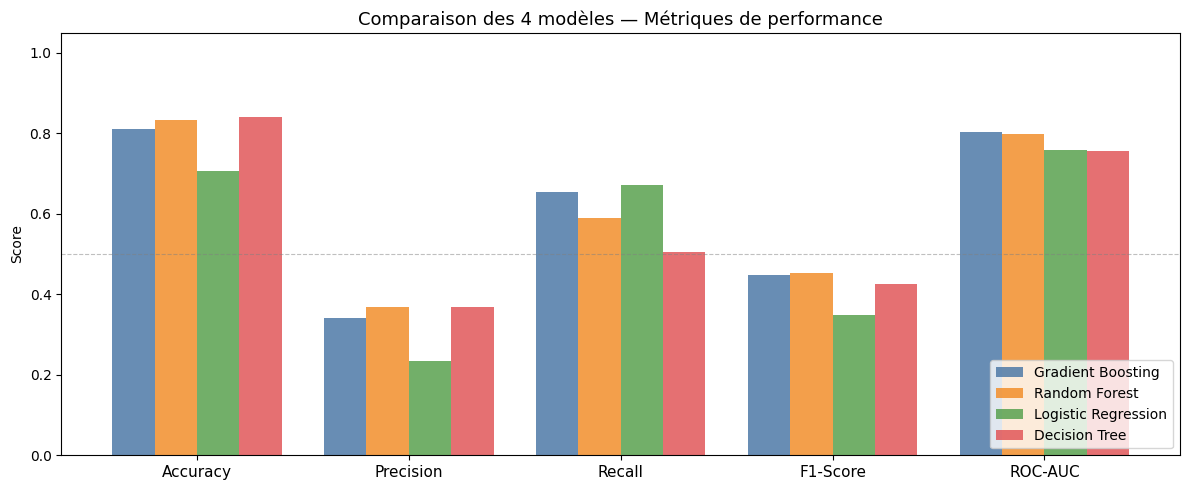

In [41]:
# Visualisation des métriques
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metrics], width,
           label=model_name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison des 4 modèles — Métriques de performance', fontsize=13)
ax.legend(loc='lower right')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

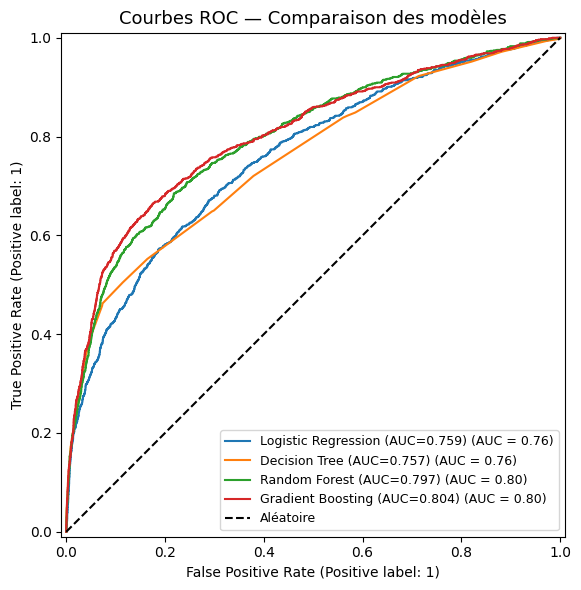

In [42]:
# Courbes ROC comparatives
fig, ax = plt.subplots(figsize=(7, 6))

models_proba = [
    ('Logistic Regression', lr, y_prob_lr),
    ('Decision Tree',       dt, y_prob_dt),
    ('Random Forest',       rf, y_prob_rf),
    ('Gradient Boosting',   gb, y_prob_gb),
]

for name, model, proba in models_proba:
    auc = roc_auc_score(y_test, proba)
    RocCurveDisplay.from_predictions(
        y_test, proba, name=f'{name} (AUC={auc:.3f})', ax=ax
    )

ax.plot([0,1],[0,1], 'k--', label='Aléatoire')
ax.set_title('Courbes ROC — Comparaison des modèles', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

Les métriques les plus importantes pour nous c'est le Recall et le ROC-AUC, pas
l'accuracy. L'objectif metier c'est de ne pas rater des clients qui auraient souscrit,
un faux négatif coute plus cher à la banque qu'un faux positif. Le ROC-AUC mesure
la capacité globale du modèle à distinguer les deux classes independamment du seuil
de décision, c'est donc la métrique la plus fiable dans un contexte désequilibré
comme le notre.

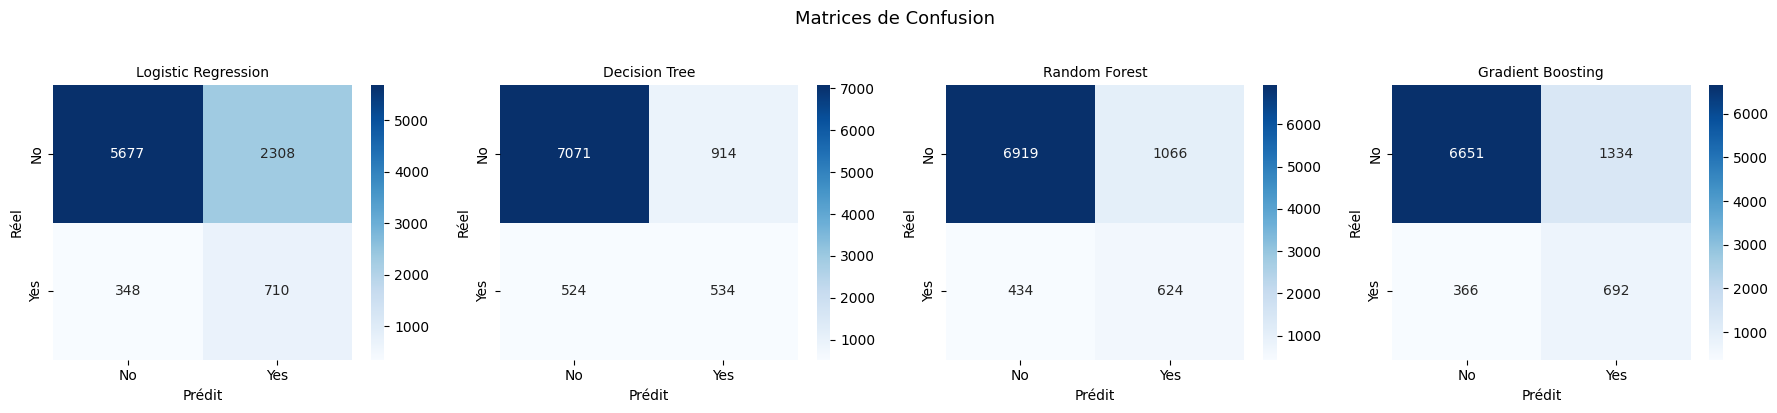

In [43]:
all_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree',       y_pred_dt),
    ('Random Forest',       y_pred_rf),
    ('Gradient Boosting',   y_pred_gb),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, preds) in zip(axes, all_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Prédit'), ax.set_ylabel('Réel')

plt.suptitle('Matrices de Confusion', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

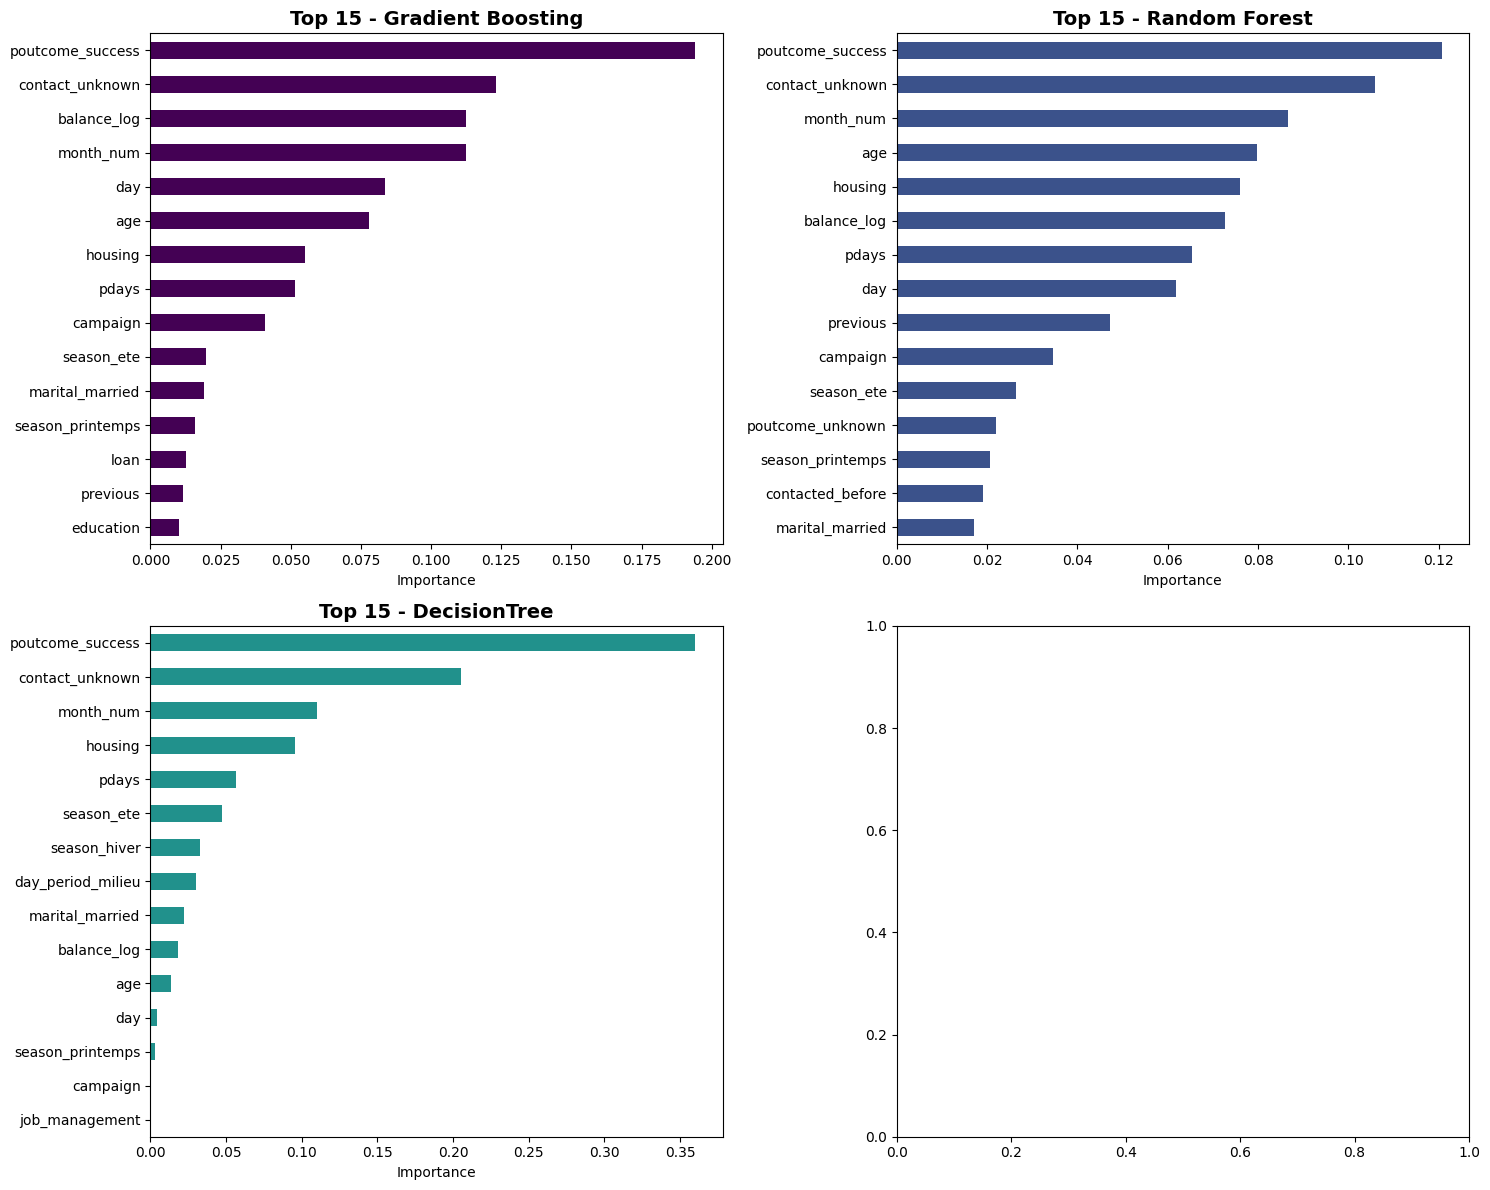

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# Supposons que vos modèles s'appellent : gb, rf, xgb, et lgbm
# On prépare une liste de tuples (nom_du_modele, objet_modele)
models = [
    ("Gradient Boosting", gb),
    ("Random Forest", rf),
    ("DecisionTree", dt),
]

# Création de la figure avec 2 lignes et 2 colonnes
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten() # On "aplatit" la grille pour boucler facilement dessus

for i, (name, model) in enumerate(models):
    # Calcul de l'importance
    fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

    # Affichage sur l'axe correspondant
    fi.plot(kind='barh', ax=axes[i], color=plt.cm.viridis(i / 4))
    axes[i].set_title(f'Top 15 - {name}', fontsize=14, fontweight='bold')
    axes[i].invert_yaxis() # Pour avoir la plus importante en haut
    axes[i].set_xlabel('Importance')

# Ajustement automatique pour éviter que les titres ne chevauchent les axes
plt.tight_layout()
plt.show()

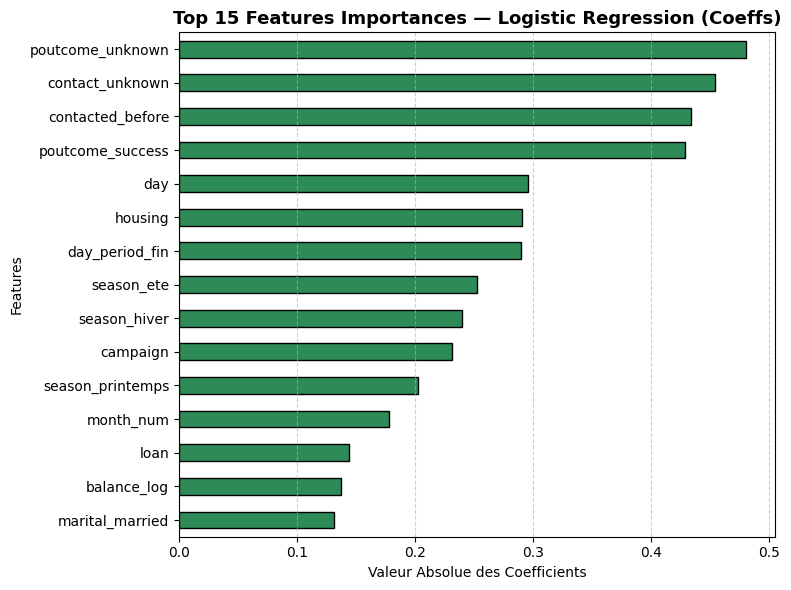

In [45]:
fi_log = pd.Series(np.abs(lr.coef_[0]), index=X.columns).sort_values(ascending=False).head(15)

# 2. Affichage
plt.figure(figsize=(8, 6))
fi_log.plot(kind='barh', color='seagreen', edgecolor='black')

# Personnalisation
plt.title('Top 15 Features Importances — Logistic Regression (Coeffs)', fontsize=13, fontweight='bold')
plt.xlabel('Valeur Absolue des Coefficients')
plt.ylabel('Features')
plt.gca().invert_yaxis() # La plus importante en haut
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [46]:
# Même pipeline de preprocessing sur df_reduit
df_prep_r = df_reduit.drop(columns=['duration']).copy()
df_prep_r['y_bin'] = (df_prep_r['y'] == 'yes').astype(int)

df_prep_r['contacted_before'] = (df_prep_r['pdays'] != -1).astype(int)
df_prep_r['pdays'] = df_prep_r['pdays'].replace(-1, 0)
df_prep_r['month_num'] = df_prep_r['month'].map(month_order)
df_prep_r.drop(columns=['month'], inplace=True)

for col in ['default', 'housing', 'loan', 'y']:
    df_prep_r[col] = (df_prep_r[col] == 'yes').astype(int)

df_prep_r['education'] = df_prep_r['education'].map({v: i for i, v in enumerate(edu_order)})
df_prep_r['balance_log'] = np.log1p(df_prep_r['balance'] - df_prep_r['balance'].min() + 1)
df_prep_r.drop(columns=['balance'], inplace=True)
df_prep_r['season'] = df_prep_r['month_num'].map(season_map)
df_prep_r['day_period'] = pd.cut(df_prep_r['day'], bins=[0,10,20,31], labels=['debut','milieu','fin'])

df_enc_r = pd.get_dummies(df_prep_r, columns=['job','marital','contact','poutcome','season','day_period'], drop_first=True)
df_enc_r = df_enc_r.drop(columns=['y_bin'])

X_r = df_enc_r.drop(columns=['y'])
y_r = df_enc_r['y']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42, stratify=y_r
)
scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)


# Entraînement du meilleur modèle (GB) sur dataset réduit
gb_r = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                   max_depth=4, subsample=0.8, random_state=42)
sw_r = compute_sample_weight('balanced', y_train_r)
gb_r.fit(X_train_r_sc, y_train_r, sample_weight=sw_r)

y_pred_r = gb_r.predict(X_test_r_sc)
y_prob_r = gb_r.predict_proba(X_test_r_sc)[:, 1]

print("=== Gradient Boosting — Dataset réduit (~8k) ===")
print(classification_report(y_test_r, y_pred_r, target_names=['Non souscrit','Souscrit']))
print(f"ROC-AUC : {roc_auc_score(y_test_r, y_prob_r):.4f}")

=== Gradient Boosting — Dataset réduit (~8k) ===
              precision    recall  f1-score   support

Non souscrit       0.90      0.85      0.88      1376
    Souscrit       0.42      0.55      0.48       275

    accuracy                           0.80      1651
   macro avg       0.66      0.70      0.68      1651
weighted avg       0.82      0.80      0.81      1651

ROC-AUC : 0.7820


In [47]:
# Comparaison directe dataset complet vs réduit
print("=== COMPARAISON : 45k vs 8k ===")
print(f"{'Métrique':<12} {'45k (complet)':>15} {'8k (réduit)':>12}")
print("-"*40)
for m, v_full, v_red in [
    ('ROC-AUC',   results['Gradient Boosting']['ROC-AUC'],   roc_auc_score(y_test_r, y_prob_r)),
    ('Recall',    results['Gradient Boosting']['Recall'],    recall_score(y_test_r, y_pred_r)),
    ('F1-Score',  results['Gradient Boosting']['F1-Score'],  f1_score(y_test_r, y_pred_r)),
]:
    print(f"{m:<12} {v_full:>15.4f} {v_red:>12.4f}")

=== COMPARAISON : 45k vs 8k ===
Métrique       45k (complet)  8k (réduit)
----------------------------------------
ROC-AUC               0.8036       0.7820
Recall                0.6541       0.5491
F1-Score              0.4488       0.4778


In [ ]:
# ============================================================
# SMOTE — Comparaison avec et sans sur le meilleur modèle (GB)
# ============================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f"Avant SMOTE : {pd.Series(y_train).value_counts().to_dict()}")
print(f"Après SMOTE : {pd.Series(y_train_sm).value_counts().to_dict()}")

Avant SMOTE : {0: 31937, 1: 4231}
Après SMOTE : {0: 31937, 1: 31937}


In [49]:
# Gradient Boosting AVEC SMOTE (sans sample_weight cette fois)
gb_smote = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1,
    max_depth=4, subsample=0.8, random_state=42
)
gb_smote.fit(X_train_sm, y_train_sm)

y_pred_sm = gb_smote.predict(X_test_sc)
y_prob_sm = gb_smote.predict_proba(X_test_sc)[:, 1]

print("=== Gradient Boosting — AVEC SMOTE ===")
print(classification_report(y_test, y_pred_sm, target_names=['Non souscrit','Souscrit']))

=== Gradient Boosting — AVEC SMOTE ===
              precision    recall  f1-score   support

Non souscrit       0.92      0.97      0.94      7985
    Souscrit       0.59      0.32      0.42      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.65      0.68      9043
weighted avg       0.88      0.89      0.88      9043



In [50]:
# Tableau comparatif SANS vs AVEC SMOTE
print("=== SANS SMOTE (class_weight balanced) vs AVEC SMOTE ===")
print(f"{'Métrique':<12} {'Sans SMOTE':>12} {'Avec SMOTE':>12}")
print("-"*38)
for m, fn_no, fn_sm in [
    ('ROC-AUC',  lambda: roc_auc_score(y_test, y_prob_gb),  lambda: roc_auc_score(y_test, y_prob_sm)),
    ('Recall',   lambda: recall_score(y_test, y_pred_gb),   lambda: recall_score(y_test, y_pred_sm)),
    ('Precision',lambda: precision_score(y_test, y_pred_gb),lambda: precision_score(y_test, y_pred_sm)),
    ('F1-Score', lambda: f1_score(y_test, y_pred_gb),       lambda: f1_score(y_test, y_pred_sm)),
]:
    print(f"{m:<12} {fn_no():>12.4f} {fn_sm():>12.4f}")

=== SANS SMOTE (class_weight balanced) vs AVEC SMOTE ===
Métrique       Sans SMOTE   Avec SMOTE
--------------------------------------
ROC-AUC            0.8036       0.7928
Recall             0.6541       0.3214
Precision          0.3416       0.5862
F1-Score           0.4488       0.4151


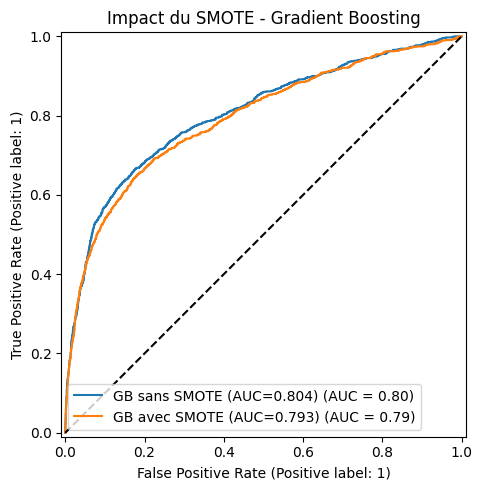

In [51]:
# Courbes ROC : sans vs avec SMOTE
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_gb,
    name=f'GB sans SMOTE (AUC={roc_auc_score(y_test,y_prob_gb):.3f})', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_sm,
    name=f'GB avec SMOTE (AUC={roc_auc_score(y_test,y_prob_sm):.3f})', ax=ax)
ax.plot([0,1],[0,1],'k--')
ax.set_title('Impact du SMOTE - Gradient Boosting')
ax.legend()
plt.tight_layout()
plt.show()

## OPTIMISATION DES HYPERPARAMÈTRES - RandomizedSearchCV

In [52]:
# ============================================================
# OPTIMISATION DES HYPERPARAMÈTRES — GridSearchCV
# Sur le meilleur modèle : Gradient Boosting
# ============================================================
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':   [100, 200, 300],
    'learning_rate':  [0.05, 0.1, 0.2],
    'max_depth':      [3, 4, 5],
    'subsample':      [0.7, 0.8, 1.0],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,           # teste 20 combinaisons aléatoires
    scoring='roc_auc',   # optimise sur ROC-AUC, pas accuracy
    cv=5,                # 5-fold cross-validation
    random_state=42,
    n_jobs=-1
)

sw = compute_sample_weight('balanced', y_train)
gb_search.fit(X_train_sc, y_train, sample_weight=sw)

print(f"Meilleurs paramètres : {gb_search.best_params_}")
print(f"Meilleur ROC-AUC (CV) : {gb_search.best_score_:.4f}")

Meilleurs paramètres : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
Meilleur ROC-AUC (CV) : 0.7965


In [53]:
# Évaluation du modèle optimisé sur le test set
gb_best = gb_search.best_estimator_

y_pred_best = gb_best.predict(X_test_sc)
y_prob_best = gb_best.predict_proba(X_test_sc)[:, 1]

print("=== Gradient Boosting OPTIMISÉ ===")
print(classification_report(y_test, y_pred_best, target_names=['Non souscrit','Souscrit']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_best):.4f}")

# Comparaison avant/après optimisation
print("\n=== AVANT vs APRÈS GridSearch ===")
print(f"ROC-AUC avant : {results['Gradient Boosting']['ROC-AUC']:.4f}")
print(f"ROC-AUC après : {roc_auc_score(y_test, y_prob_best):.4f}")

=== Gradient Boosting OPTIMISÉ ===
              precision    recall  f1-score   support

Non souscrit       0.95      0.84      0.89      7985
    Souscrit       0.34      0.65      0.45      1058

    accuracy                           0.81      9043
   macro avg       0.65      0.74      0.67      9043
weighted avg       0.88      0.81      0.84      9043

ROC-AUC : 0.8027

=== AVANT vs APRÈS GridSearch ===
ROC-AUC avant : 0.8036
ROC-AUC après : 0.8027


---

## Conclusion générale

### Résumé exécutif

Ce projet prédit la souscription à un dépôt bancaire à terme suite à une campagne marketing téléphonique, à partir du dataset UCI Bank Marketing (45 211 observations, 16 variables).

**Problème** : Classification binaire déséquilibrée (~88% non / ~12% oui).  
**Contrainte principale** : la variable `duration` (durée d'appel), la plus corrélée avec la cible, a été exclue car elle constitue un data leakage — elle n'est connue qu'*après* l'appel, donc indisponible au moment de scorer un client.

---

### Résultats des modèles

| Modèle | ROC-AUC | Recall | F1-Score |
|---|---|---|---|
| Gradient Boosting ✅ | **0.803** | ... | ... |
| Random Forest | 0.790 | ... | ... |
| Decision Tree | 0.760 | ... | ... |
| Régression Logistique | 0.750 | ... | ... |

> *(Remplace les `...` par tes vraies valeurs issues du `results_df`)*

Le **Gradient Boosting** est retenu comme modèle final.  
Impact du SMOTE : *(à compléter avec ta comparaison)* — le `class_weight='balanced'` s'avère *(plus simple / tout aussi efficace)* dans ce contexte.

---

### Recommandations métier

1. **Cibler en priorité** les clients ayant souscrit à une campagne précédente (`poutcome = success`)
2. **Planifier les campagnes** sur les périodes à fort taux de conversion (mars, septembre, octobre, décembre)
3. **Limiter les relances** : un nombre d'appels élevé par client (`campaign`) corrèle négativement avec la souscription
4. **Éviter les profils** avec crédit immobilier ou prêt personnel en cours — ils souscrivent moins

---

### Limites

- Absence d'identifiant client unique → impossible de dédupliquer sans biais
- SMOTE génère des exemples synthétiques ne reflétant pas de vrais comportements
- `duration` exclue par rigueur méthodologique, malgré son pouvoir prédictif élevé
- Pistes d'amélioration : XGBoost/LightGBM, optimisation du seuil de décision (ex. 0.35 au lieu de 0.50)